In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## Helper functions

In [6]:
# imports needed for reloading
import importlib
import sys

# To avoid issues with cached python code that is often changing during development,
# we forcibly reload those modules
modules = ['lib.text_util', 'lib.wrangler', 'lib.imputer']

for module in modules:
    if module in sys.modules:
        try:
            importlib.reload(sys.modules[module])
        except:
            print(f"Error reloading module: {module}")

# text helpers used to make text output more readable
import lib.text_util as tu

# data wrangling helpers
import lib.wrangler as wr

# data imputation helpers
import lib.imputer as im

# to test text_util, uncomment the following line
tu.demo_text_print()

Show Red
Show Bold
Show Combo Yellow, Italic, Bold
Show Bold and Blue


In [7]:
incomes = pd.read_csv('adultcensusincome - adultcensusincome.csv')
#incomes
print(incomes.columns)
print(incomes.describe())
incomes

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
cou

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Data Wrangling

In [9]:
wr.print_col_info(incomes)

#wr.detailed_col_info(incomes)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
Shape: (32561, 15)
Dtypes: age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object
Sample values for object columns:

Sample values for object columns:
workclass: ['?', 'Private', '?']
education: ['HS-grad', 'HS-grad', 'Some-college']
marital.status: ['Widowed', 'Widowed', 'Widowed']
occupation: ['?', 'Exec-managerial', '?']
relationship: ['Not-in-family', 'Not-in-family', 'Unmarried']
race: ['White', 'White', 'Black']
sex: ['Female', 'Female', 'Female

In [28]:
#unknown_df = im.replace_missing_values(incomes)
udf = im.replace_missing_values(incomes)

In [29]:
udf

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,unknown,77053,HS-grad,9,Widowed,unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,unknown,186061,Some-college,10,Widowed,unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [20]:
print(udf['income'].value_counts())
print(udf['income'].value_counts(normalize=True).round(3))

income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


In [37]:
print(f"incomes['income'].isna().sum(): {incomes['income'].isnull().sum()}")
print(f"udf['income'].isna().sum(): {udf['income'].isnull().sum()}")

incomes['income'].isna().sum(): 0
udf['income'].isna().sum(): 0


### Bar plot of income classes

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64
Balanced (40–60% each)? False


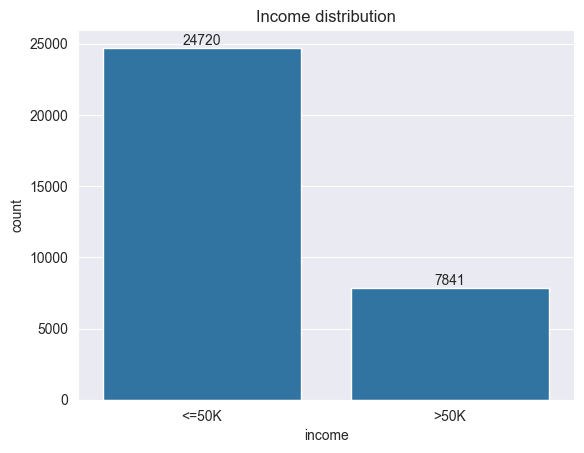

In [36]:
# Python
import seaborn as sns
import matplotlib.pyplot as plt

share = incomes['income'].value_counts(normalize=True)
print(share)
is_balanced = share.between(0.4, 0.6).all()
print(f"Balanced (40–60% each)? {is_balanced}")


ax = sns.countplot(data=incomes, x='income')
ax.bar_label(ax.containers[0])
plt.title('Income distribution')
plt.show()